# 02. 微分・計算グラフ・誤差逆伝播 — 勾配はどう流れるか

## この章で分かること

- ニューラルネットの学習を支える **連鎖律(チェインルール)** の正体
- 計算を **計算グラフ** として表すと、微分が「逆向きにたどるだけ」になること
- **誤差逆伝播 (backpropagation)** を、小さな自作 autograd エンジンで体感する
- 実装が正しいかを **数値勾配チェック** で検証する方法

この章のゴールは、「`loss.backward()` の中で何が起きているか」を完全に開けて見せることです。

## 1. Big Picture — 学習 = 勾配を下る

学習とは、損失 $L(\theta)$ を小さくするパラメータ $\theta$ を探すことでした。
そのために使うのが **勾配降下法**:

$$
\theta \leftarrow \theta - \eta\, \frac{\partial L}{\partial \theta}
$$

- $\eta$: 学習率(step size)
- $\partial L / \partial \theta$: 各パラメータを少し動かすと損失がどれだけ変わるか

問題は、$\theta$ が何百万個もあるとき、この勾配をどう **効率よく** 計算するか。
その答えが **誤差逆伝播** で、核心は高校でも習う **連鎖律** ひとつです。

## 2. Problem — 合成関数の微分

次の関数を考えます。

$$
L = (y - \hat{y})^2, \qquad \hat{y} = \tanh(w x + b)
$$

知りたいのは $\partial L / \partial w$ と $\partial L / \partial b$。
$L$ は $\hat{y}$ の関数、$\hat{y}$ は $w, b$ の関数 — **入れ子(合成)** になっています。
手で微分すると連鎖律で項が増えていきます。これを機械的に、かつ大規模に行いたい。

## 3. Intuition — 連鎖律は「局所の掛け算」

連鎖律はこう読めます。

$$
\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w}
\qquad (z = wx + b)
$$

それぞれの因子は **その場(局所)の微分** にすぎません。

- $\partial L / \partial \hat{y} = -2(y - \hat{y})$
- $\partial \hat{y} / \partial z = 1 - \tanh^2(z)$
- $\partial z / \partial w = x$

全体の勾配は、これらを **掛け合わせる** だけ。
「出力側から入力側へ、局所微分を掛けながら伝えていく」— これが逆伝播の直感です。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=4, suppress=True)

## 4. Visualization — 計算グラフ

計算を **ノード(演算)と矢印(データの流れ)** のグラフにします。
前向き(forward)に値を計算し、後ろ向き(backward)に勾配を流します。

自作の `Value` クラス(`nn_textbook.autograd`)で上の式のグラフを組み、
networkx で描きます。各ノードに **値(data)** と **勾配(grad)** を表示します。

In [2]:
# Build the graph L = (y - yhat)^2 with yhat = tanh(w*x + b) using our tiny autograd.
from nn_textbook.autograd import Value, topological_order

x = Value(1.5, label="x")
w = Value(0.8, label="w")
b = Value(-0.5, label="b")
y = Value(1.0, label="y")

z = w * x + b
z.label = "z"
yhat = z.tanh()
yhat.label = "yhat"
loss = (y - yhat) ** 2
loss.label = "L"

loss.backward()    # fills .grad on every node
print(f"forward: z={z.data:.4f}, yhat={yhat.data:.4f}, loss={loss.data:.4f}")
print(f"grad w = {w.grad:.4f}, grad b = {b.grad:.4f}")

forward: z=0.7000, yhat=0.6044, loss=0.1565
grad w = -0.7534, grad b = -0.5022


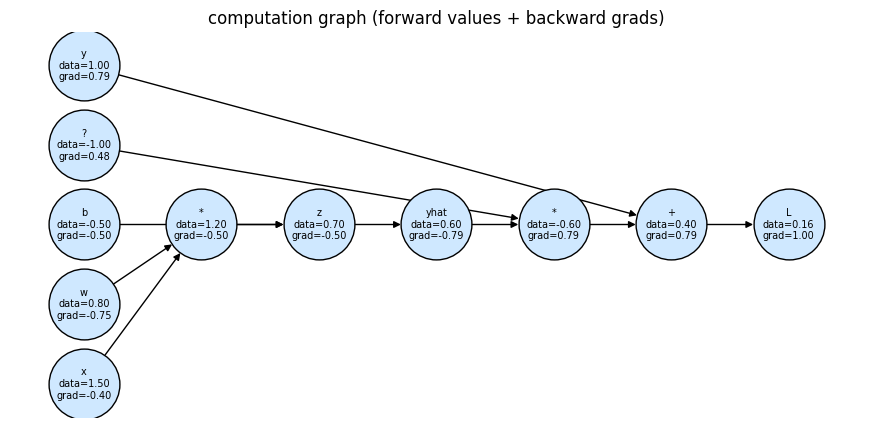

In [3]:
# Draw the computation graph with node values and gradients.
import networkx as nx


def draw_graph(root):
    nodes = topological_order(root)
    G = nx.DiGraph()
    labels = {}
    for n in nodes:
        nid = id(n)
        name = n.label or n._op or "?"
        labels[nid] = f"{name}\ndata={n.data:.2f}\ngrad={n.grad:.2f}"
        G.add_node(nid)
        for child in n._prev:
            G.add_edge(id(child), nid)
    # Layer nodes left-to-right by topological depth.
    depth = {}
    for n in nodes:
        d = 0
        for child in n._prev:
            d = max(d, depth[id(child)] + 1)
        depth[id(n)] = d
    pos = {}
    from collections import defaultdict
    by_depth = defaultdict(list)
    for nid, d in depth.items():
        by_depth[d].append(nid)
    for d, ids in by_depth.items():
        for i, nid in enumerate(ids):
            pos[nid] = (d, -i + len(ids) / 2)

    fig, ax = plt.subplots(figsize=(11, 5))
    nx.draw(G, pos, ax=ax, labels=labels, node_color="#cfe8ff", node_size=2600,
            font_size=7, arrows=True, edgecolors="black")
    ax.set_title("computation graph (forward values + backward grads)")
    plt.show()


draw_graph(loss)

グラフの各ノードの `grad` が、出力 $L$ をそのノードで微分した値です。
矢印を逆向きにたどりながら局所微分を掛けていけば、葉(w, b, x)の勾配が手に入ります。

## 5. Definition — forward と backward

**forward pass**: 入力からグラフをたどって各ノードの値を計算する。

**backward pass(逆伝播)**: 出力ノードの勾配を 1 とし、
**逆トポロジカル順** に各ノードの局所微分を適用して、すべてのノードの勾配を埋める。

自作 `Value` の各演算は、forward で値を作ると同時に、
「自分の入力に勾配をどう配るか」という局所ルール `_backward` を仕込みます。
たとえば乗算 $c = a \cdot b$ なら:

$$
\frac{\partial L}{\partial a} \mathrel{+}= b \cdot \frac{\partial L}{\partial c}, \qquad
\frac{\partial L}{\partial b} \mathrel{+}= a \cdot \frac{\partial L}{\partial c}
$$

「$+=$」なのは、同じノードが複数の場所で使われたとき勾配を **足し合わせる** ためです
(多変数連鎖律)。

In [4]:
# Inspect the local backward rule of one node. Multiplication routes the
# upstream gradient to each input, scaled by the OTHER input's value.
a = Value(3.0)
b = Value(-2.0)
c = a * b
c.backward()
print(f"c = a*b = {c.data}")
print(f"dc/da = b = {a.grad}  (got via _backward)")
print(f"dc/db = a = {b.grad}")

c = a*b = -6.0
dc/da = b = -2.0  (got via _backward)
dc/db = a = 3.0


## 6. Computation — 数値勾配チェック

実装が正しいかは、勾配の定義そのもの(中心差分)と比べれば確かめられます。

$$
\frac{\partial L}{\partial w} \approx \frac{L(w + h) - L(w - h)}{2h}
$$

これを **gradient checking** と呼びます。autograd の解析勾配と数値勾配が一致すれば安心です。

In [5]:
# Numerical vs analytical gradient for w and b.
def compute_loss(w_val, b_val):
    x = Value(1.5); w = Value(w_val); b = Value(b_val); y = Value(1.0)
    yhat = (w * x + b).tanh()
    return ((y - yhat) ** 2).data

h = 1e-6
num_w = (compute_loss(0.8 + h, -0.5) - compute_loss(0.8 - h, -0.5)) / (2 * h)
num_b = (compute_loss(0.8, -0.5 + h) - compute_loss(0.8, -0.5 - h)) / (2 * h)

# Analytical grads from autograd (recompute the graph).
x = Value(1.5); w = Value(0.8); b = Value(-0.5); y = Value(1.0)
((y - (w * x + b).tanh()) ** 2).backward()

print(f"grad w: analytic={w.grad:.6f}  numeric={num_w:.6f}  diff={abs(w.grad - num_w):.2e}")
print(f"grad b: analytic={b.grad:.6f}  numeric={num_b:.6f}  diff={abs(b.grad - num_b):.2e}")

grad w: analytic=-0.753370  numeric=-0.753370  diff=1.12e-11
grad b: analytic=-0.502247  numeric=-0.502247  diff=2.95e-11


差は $10^{-11}$ オーダー — 実装は正しいと確認できました。
($h = 10^{-6}$ の中心差分は理論上 $O(h^2) = 10^{-12}$ 程度の打ち切り誤差を持つので、この一致は期待どおりです。)

### 自作 autograd と PyTorch autograd の一致

PyTorch の `backward()` も、まったく同じ計算グラフ + 逆伝播をしています。
同じ式で勾配が一致することを見ます。

In [6]:
# Our scalar autograd agrees with PyTorch's autograd on the same expression.
import torch

xt = torch.tensor(1.5)
wt = torch.tensor(0.8, requires_grad=True)
bt = torch.tensor(-0.5, requires_grad=True)
yt = torch.tensor(1.0)
loss_t = (yt - torch.tanh(wt * xt + bt)) ** 2
loss_t.backward()

print(f"PyTorch : grad w = {wt.grad.item():.6f}, grad b = {bt.grad.item():.6f}")
print(f"ours    : grad w = {w.grad:.6f}, grad b = {b.grad:.6f}")

PyTorch : grad w = -0.753370, grad b = -0.502247
ours    : grad w = -0.753370, grad b = -0.502247


## 7. Invariant — 逆伝播が保存する計算量

逆伝播の威力は **効率** にあります。

- forward は 1 回でグラフ全体の値を計算する
- backward も 1 回でグラフ全体の **すべてのパラメータの勾配** を計算する

パラメータが 100 万個でも、勾配計算のコストは forward の定数倍。
もし数値微分(パラメータごとに $L$ を 2 回評価)を使えば 200 万回の forward が必要 — 桁違いです。
**「1 回の逆伝播で全勾配が手に入る」** が、深層学習を現実的にした鍵です。

In [7]:
# Backprop fills every gradient in one backward pass over a small MLP-like graph.
def tiny_network(inputs, weights):
    h = sum(wi * xi for wi, xi in zip(weights, inputs))
    return h.tanh()

inputs = [Value(0.5), Value(-1.0), Value(2.0)]
weights = [Value(0.3), Value(-0.7), Value(0.1)]
out = tiny_network(inputs, weights)
out.backward()
print("one backward pass -> all weight grads:")
for i, wv in enumerate(weights):
    print(f"  d out / d w{i} = {wv.grad:.4f}")

one backward pass -> all weight grads:
  d out / d w0 = 0.1944
  d out / d w1 = -0.3888
  d out / d w2 = 0.7776


## 8. Failure Mode — 勾配が壊れるとき

逆伝播は局所微分の **掛け算の連鎖** なので、長い連鎖では掛け算が暴れます。

- 各factorが 1 より小さい → 積が指数的に 0 へ:**勾配消失 (vanishing)**
- 各factorが 1 より大きい → 積が指数的に発散:**勾配爆発 (exploding)**

tanh を何段も重ねたときに勾配が縮む様子を、自作 autograd で見ます。

depth  1: d(out)/d(input) = 4.869e-01
depth  2: d(out)/d(input) = 3.030e-01
depth  5: d(out)/d(input) = 1.256e-01
depth 10: d(out)/d(input) = 5.516e-02
depth 20: d(out)/d(input) = 2.213e-02
depth 40: d(out)/d(input) = 8.397e-03


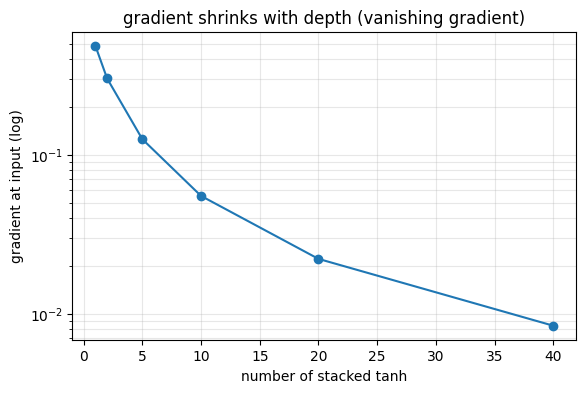

In [8]:
# Stacking many tanh units shrinks the gradient (a preview of vanishing gradients).
def deep_tanh_chain(x0_val, depth):
    x = Value(x0_val)
    first = x
    for _ in range(depth):
        x = x.tanh()
    x.backward()
    return first.grad

depths = [1, 2, 5, 10, 20, 40]
grads = [deep_tanh_chain(0.9, d) for d in depths]
for d, g in zip(depths, grads, strict=True):
    print(f"depth {d:>2}: d(out)/d(input) = {g:.3e}")

plt.figure(figsize=(6.5, 4))
plt.semilogy(depths, grads, "o-")
plt.xlabel("number of stacked tanh"); plt.ylabel("gradient at input (log)")
plt.title("gradient shrinks with depth (vanishing gradient)")
plt.grid(alpha=0.3, which="both")
plt.show()

深さとともに勾配は単調に縮み、この例では 40 段で約 60 分の 1 になりました。
(純粋な tanh の反復は値が 0 に引き込まれて局所微分が 1 に近づくため、縮小は次第に緩みます。
実際のネットワークでは各段に重み行列の積も掛かるので、消失・爆発はもっと急激に起きます。)
この問題への対処(初期化・正規化・残差接続)が 04 章の主題です。

## 9. Application — フレームワークの autograd

PyTorch / JAX / TensorFlow の自動微分は、本章で作ったものの大規模・テンソル版です。

- ノードはスカラーではなくテンソル
- 局所微分は **ヤコビアン**(の積)
- 同じ「forward でグラフ構築 → backward で逆伝播」の原理

だから `loss.backward()` は魔法ではなく、**この章のグラフ走査そのもの** です。
次章ではこの逆伝播を、行列(層)レベルで NumPy 実装し、MLP を一から学習させます。

## 10. まとめ

- 学習 = 勾配降下。その勾配は **連鎖律** で機械的に計算できる。
- 計算グラフ: forward で値を作り、backward で **局所微分を逆順に掛けて** 全ノードの勾配を埋める。
- **1 回の backward で全パラメータの勾配** が得られる(reverse-mode 自動微分の効率)。
- 実装の正しさは **数値勾配チェック**(中心差分)で検証できる。
- `loss.backward()` の中身はこの章のグラフ走査そのもの。
- 長い連鎖は掛け算で勾配が **消える/爆発する** — 対策は 04 章。

## 11. Exercises

1. $L = (a b + c)^2$ のグラフを `Value` で組み、$a, b, c$ の勾配を手計算と照合せよ。
2. `relu` を使った式 $L = \mathrm{relu}(wx + b)$ の勾配を、$wx+b>0$ と $<0$ の両方で確かめよ。
3. 数値勾配チェックの $h$ を $10^{-2}, 10^{-6}, 10^{-10}$ と変え、誤差がどう変わるか観察せよ
   (小さすぎると桁落ちで悪化する)。
4. tanh の代わりに恒等関数(活性化なし)で深い連鎖を作ると、勾配が消えないことを確認せよ。
5. (発展)`Value` に `exp` を使った式 $\sigma(x) = 1/(1+e^{-x})$ を組み、
   その勾配が $\sigma(x)(1-\sigma(x))$ になることを数値チェックで確かめよ。

## 12. Advanced Notes

**ヤコビアンとベクトル-ヤコビアン積 (VJP)。** テンソルを扱う本物の autograd では、
各ノードの局所微分はヤコビアン行列 $J$ です。逆伝播は上流勾配 $v$ に対して
$v^\top J$ を計算する **VJP** の連鎖になります。ヤコビアンを陽に作らず、
$v^\top J$ を直接計算できる演算ごとのルールを持つのがポイント(メモリ効率)。

**reverse-mode vs forward-mode。** 本章の逆伝播は reverse-mode 自動微分です。
出力 1 個・入力多数(まさに損失とパラメータ)のとき最も効率的。
逆に入力 1 個・出力多数なら forward-mode が有利。深層学習が reverse-mode 一色なのは、
スカラー損失を大量パラメータで微分するからです。

**計算グラフの保存とメモリ。** backward には forward の中間値が必要なので、
フレームワークは forward 時にそれらを保持します(activation memory)。
これが大規模モデルのメモリを食う主因で、gradient checkpointing は
「一部を保存せず backward 時に再計算する」省メモリ技法です。

**`+=` の意味(多変数連鎖律)。** あるノードが $k$ 箇所で使われると、
全体微分はその $k$ 経路の寄与の **和** になります($\frac{dL}{dx} = \sum_i \frac{dL}{du_i}\frac{du_i}{dx}$)。
だから `self.grad += ...` と累積するのが正しく、`=` で上書きするとバグになります。